OpenPNM testing tutorials from https://openpnm.org/examples/tutorial

In [1]:
# %pip install pypardiso
import openpnm as op
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
op.visualization.set_mpl_style()

Regular network!

In [2]:
# Input data
# Data loading using Pandas and numpy (brute force version)
inputpoints_pd=pd.read_csv('results.100s.Mono.txt',skiprows=18,header=None,sep=',')
inputpoints=np.array([inputpoints_pd[0].values,inputpoints_pd[1].values,inputpoints_pd[2].values])

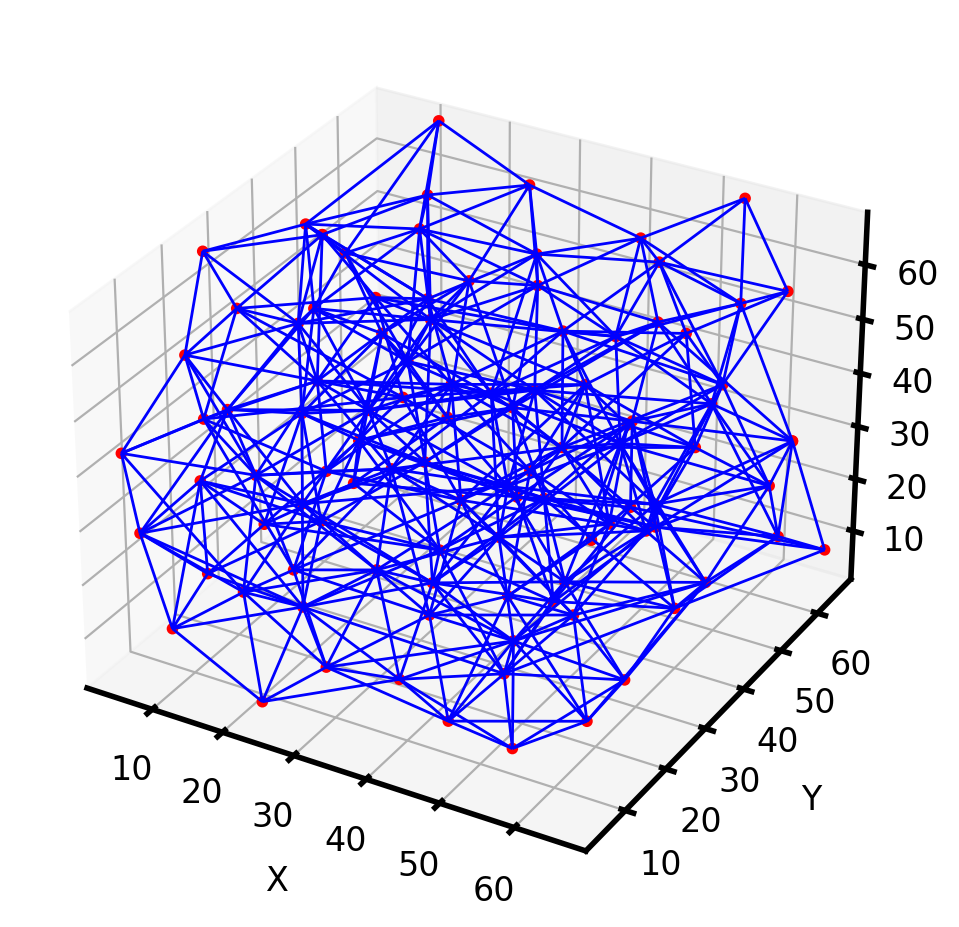

In [3]:
# Delaunay - Random generation
# np.random.seed(0)
# pn = op.network.Delaunay(points=50, shape=[5e-6,5e-6,5e-6])

# Delaunay - Input points
xmax=np.max(inputpoints[0,:]); ymax=np.max(inputpoints[1,:]); zmax=np.max(inputpoints[2,:]) 
pn = op.network.Delaunay(points=inputpoints.T, shape=[xmax,ymax,zmax])
pn.add_model_collection(op.models.collections.geometry.spheres_and_cylinders)     # This is needed to build the geometry (Demo generates it automatically)
pn.regenerate_models()

# Basic plot
ax = op.visualization.plot_coordinates(pn)
ax = op.visualization.plot_connections(pn, ax=ax)

In [4]:
# Since not using a cubic model, I define 'inlet' and 'outlet' labels for performing the calculations
porecoords=pn['pore.coords']                  # I extract coordinates
# Labels can be used to define inlet and outlet. This section labels based on values below or above thresholds along main directions 0, 1, 2.
# This approach does not allow direct calculation of permeability as with the cubic model (needs additional work)
inlet_threshold=10                            # Define thresholds
outlet_threshold=60
inlet_index=np.where(porecoords[:,1]<inlet_threshold)[0]             # Set thresholds
outlet_index=np.where(porecoords[:,1]>outlet_threshold)[0]
# print(np.where(porecoords[:,1]>outlet_threshold)[0])
pn['pore.inlet'] = False
pn['pore.outlet'] = False
pn['pore.inlet'][inlet_index] = True
pn['pore.outlet'][outlet_index] = True

In [5]:
print('\nNumber of pores:',pn.Np)
print('\nNumber of throats:',pn.Nt)

print(pn)


Number of pores: 103

Number of throats: 502

══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Delaunay at 0x242899bd680>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.coords                                                     103 / 103
  3  throat.conns                                                    502 / 502
  4  pore.coordination_number                                        103 / 103
  5  pore.max_size                                                   103 / 103
  6  throat.spacing                                                  502 / 502
  7  pore.seed                                                       103 / 103
  8  pore.diameter                                                   103 / 103
  9  throat.max_size              

In [ ]:
print(pn['pore.coords'])

[[19.3102    7.00642  21.8734  ]
 [ 6.17693  44.7204   44.6181  ]
 [21.9859   46.397    47.2016  ]
 [65.4142   33.3622   48.4345  ]
 [15.6616   66.6902   39.6566  ]
 [40.714    65.5994   57.1353  ]
 [36.9299   48.5086   17.6759  ]
 [25.4623   64.7451   62.2408  ]
 [14.2982   63.4725   14.7235  ]
 [66.5031   67.54      6.41615 ]
 [41.0531   43.6166    2.89491 ]
 [34.089    51.2507   60.5405  ]
 [ 5.52247  16.8038   53.348   ]
 [62.2931   18.2643   43.7739  ]
 [69.4393    0.78508  55.9405  ]
 [44.3484   52.6951   48.209   ]
 [28.8344   60.9725   46.9501  ]
 [12.0764   31.7278   52.0881  ]
 [49.4881    3.44402  13.3973  ]
 [34.2267   50.7483   35.7341  ]
 [36.6261   13.9157    7.78572 ]
 [54.947    25.6029   60.7283  ]
 [35.7548   37.2963   44.4588  ]
 [ 5.79676  43.8074   60.6939  ]
 [45.0956    6.71959  28.5428  ]
 [13.3807   58.3469   53.7256  ]
 [28.1929   23.2929   67.7678  ]
 [16.0454    4.61336  53.6739  ]
 [32.7775   28.2592   14.0198  ]
 [25.953    41.6036    8.12398 ]
 [38.4175 

In [ ]:
pore_data_sheet = pd.DataFrame({k: pn[k] for k in pn.props(element='pore') if pn[k].ndim == 1})
pore_data_sheet
# Some inf values are observed here, which need to be trimmed

,pore.coordination_number,pore.diameter,pore.max_size,pore.seed,pore.volume
0,10.0,9.080252,16.106206,0.563773,392.005632
1,10.0,5.555944,16.106205,0.344957,89.799127
2,15.0,7.873554,16.106122,0.488855,255.570665
3,9.0,9.496057,16.106212,0.589590,448.361785
4,9.0,9.628222,16.106223,0.597795,467.344304
...,...,...,...,...,...
98,6.0,5.670750,16.106115,0.352087,95.481711
99,9.0,7.981107,16.106116,0.495533,266.187700
100,0.0,inf,inf,0.660860,inf
101,9.0,9.706085,16.106158,0.602632,478.774400


In [6]:
# Trimming bad pores
totrim = np.zeros(pn.Np, dtype=int)
porediam=pn['pore.diameter']
porediamfilter=np.where(porediam>100)[0]           # if pore diameter is above this value, then I trim it
# Steps are here: https://openpnm.org/examples/tutorials/04_graph_queries_and_manipulation.html#removing-pores
totrim[porediamfilter] = 1
offset = np.cumsum(totrim)
remap = pn.Ps - offset
Ts = pn.find_neighbor_throats(pores=porediamfilter)
op.topotools.trim(pn, throats=Ts)
mask = np.ones(pn.Np, dtype=bool)
mask[porediamfilter] = False
for k, v in pn.items():
    if k.startswith('pore.'):
        pn[k] = v[mask]
pn['throat.conns'] = remap[pn['throat.conns']]
print(pn)


══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Delaunay at 0x242899bd680>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.coords                                                     100 / 100
  3  throat.conns                                                    502 / 502
  4  pore.coordination_number                                        100 / 100
  5  pore.max_size                                                   100 / 100
  6  throat.spacing                                                  502 / 502
  7  pore.seed                                                       100 / 100
  8  pore.diameter                                                   100 / 100
  9  throat.max_size                                                 502 / 502
 

In [ ]:
pore_data_sheet = pd.DataFrame({k: pn[k] for k in pn.props(element='pore') if pn[k].ndim == 1})
pore_data_sheet
# No more inf values!!

,pore.coordination_number,pore.diameter,pore.max_size,pore.seed,pore.volume
0,10.0,9.080252,16.106206,0.563773,392.005632
1,10.0,5.555944,16.106205,0.344957,89.799127
2,15.0,7.873554,16.106122,0.488855,255.570665
3,9.0,9.496057,16.106212,0.589590,448.361785
4,9.0,9.628222,16.106223,0.597795,467.344304
...,...,...,...,...,...
95,9.0,5.558622,16.106157,0.345124,89.929050
96,6.0,5.670750,16.106115,0.352087,95.481711
97,9.0,7.981107,16.106116,0.495533,266.187700
98,9.0,9.706085,16.106158,0.602632,478.774400


In [ ]:
# Same than Demo case from now on
P_left = pn.pores('inlet')
P_back = pn.pores('outlet')
print(P_left)
print(P_back)

[ 0 14 18 24 27 31 38 52 56 62 74 87 92]
[ 4  5  7  8  9 16 37 39 53 54 60 61 72 97 98]


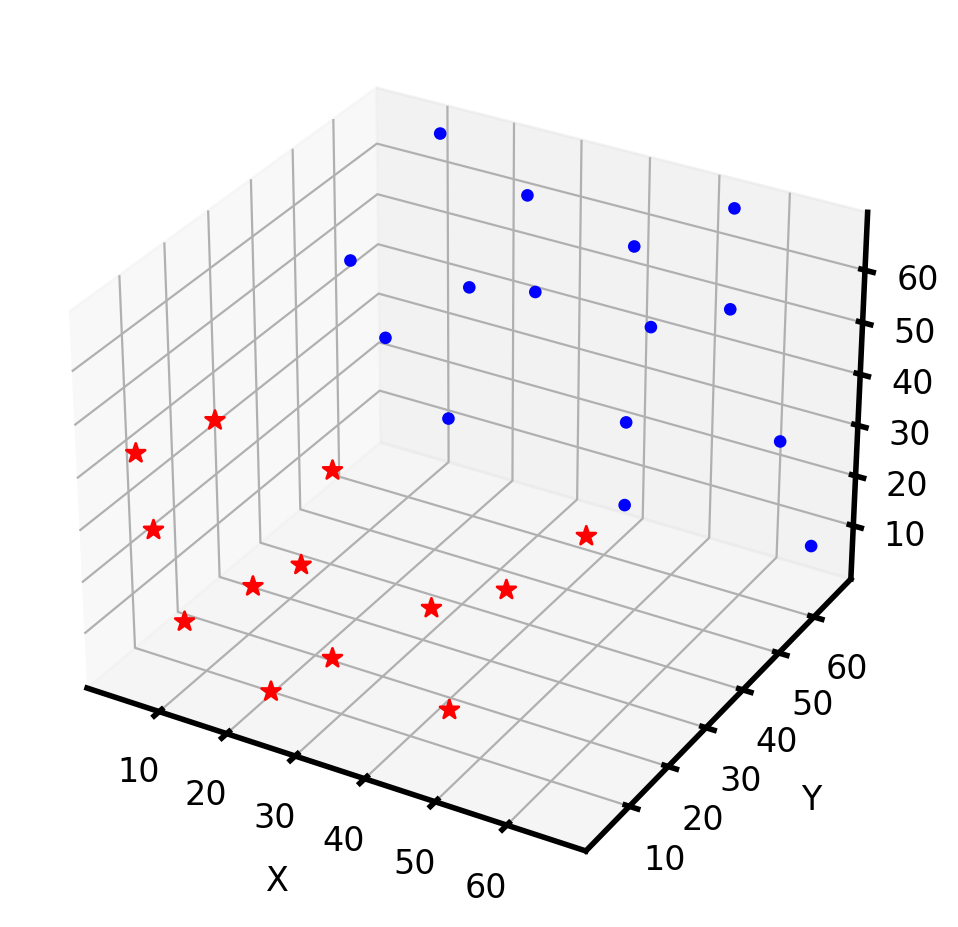

In [ ]:
fig, ax = plt.subplots()

op.visualization.plot_coordinates(pn, P_left, c='red', marker='*', 
                                  markersize=50, ax=ax)
op.visualization.plot_coordinates(pn, P_back, c='blue', marker='.', 
                                  markersize=50, ax=ax);

[ 7 11 15 16 37 53 88 97]
[51 52 53 54 55 56 57 58]


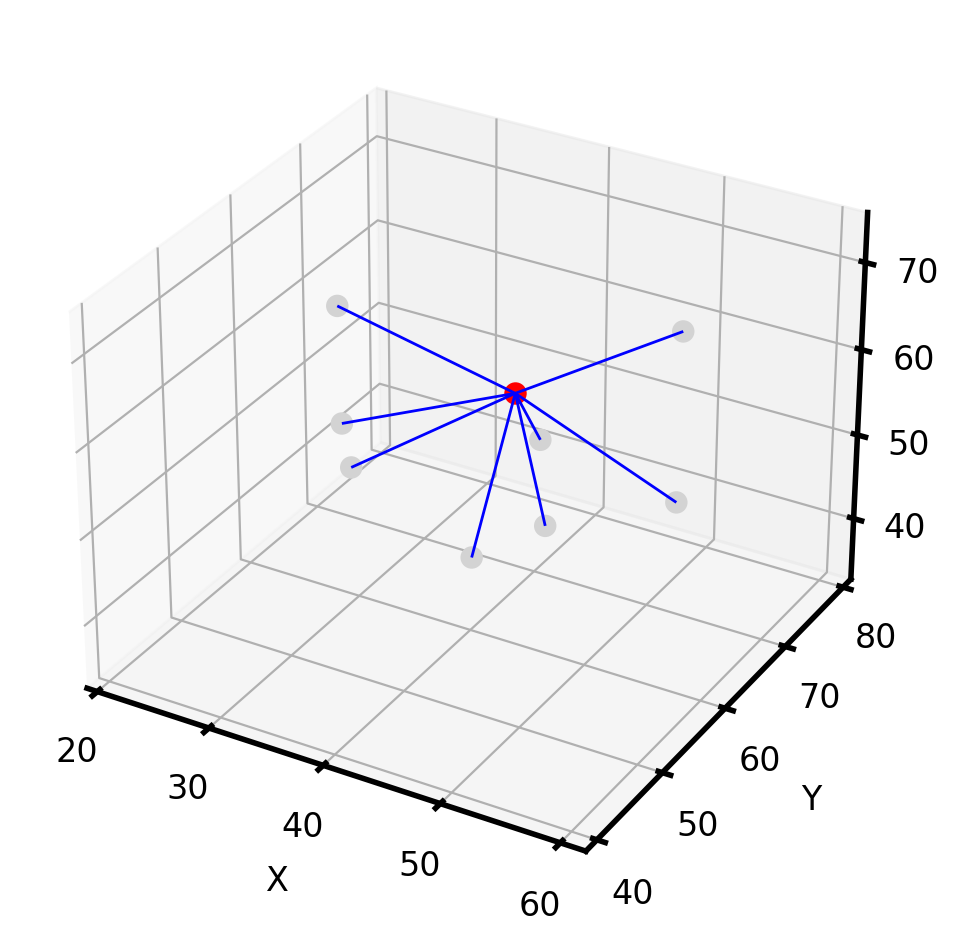

In [7]:
poreid=5
# Find and plot neighboring pores for poreid
Ps = pn.find_neighbor_pores(pores=[poreid])
print(Ps)
fig, ax = plt.subplots()

op.visualization.plot_coordinates(pn, [poreid], c='red',markersize=50, ax=ax)
op.visualization.plot_coordinates(pn, Ps, c='lightgrey',markersize=50, ax=ax)

# Find and plot neighboring throats for poreid
Ts = pn.find_neighbor_throats(pores=[poreid])
print(Ts)
op.visualization.plot_connections(pn, Ts, ax=ax)

(array([0.14209898, 0.16793515, 0.1162628 , 0.15501706, 0.14209898,
        0.09042662, 0.05167235, 0.18085324, 0.18085324, 0.06459044]),
 array([ 3.53173699,  4.30584531,  5.07995364,  5.85406196,  6.62817029,
         7.40227862,  8.17638694,  8.95049527,  9.72460359, 10.49871192,
        11.27282024]),
 <BarContainer object of 10 artists>)

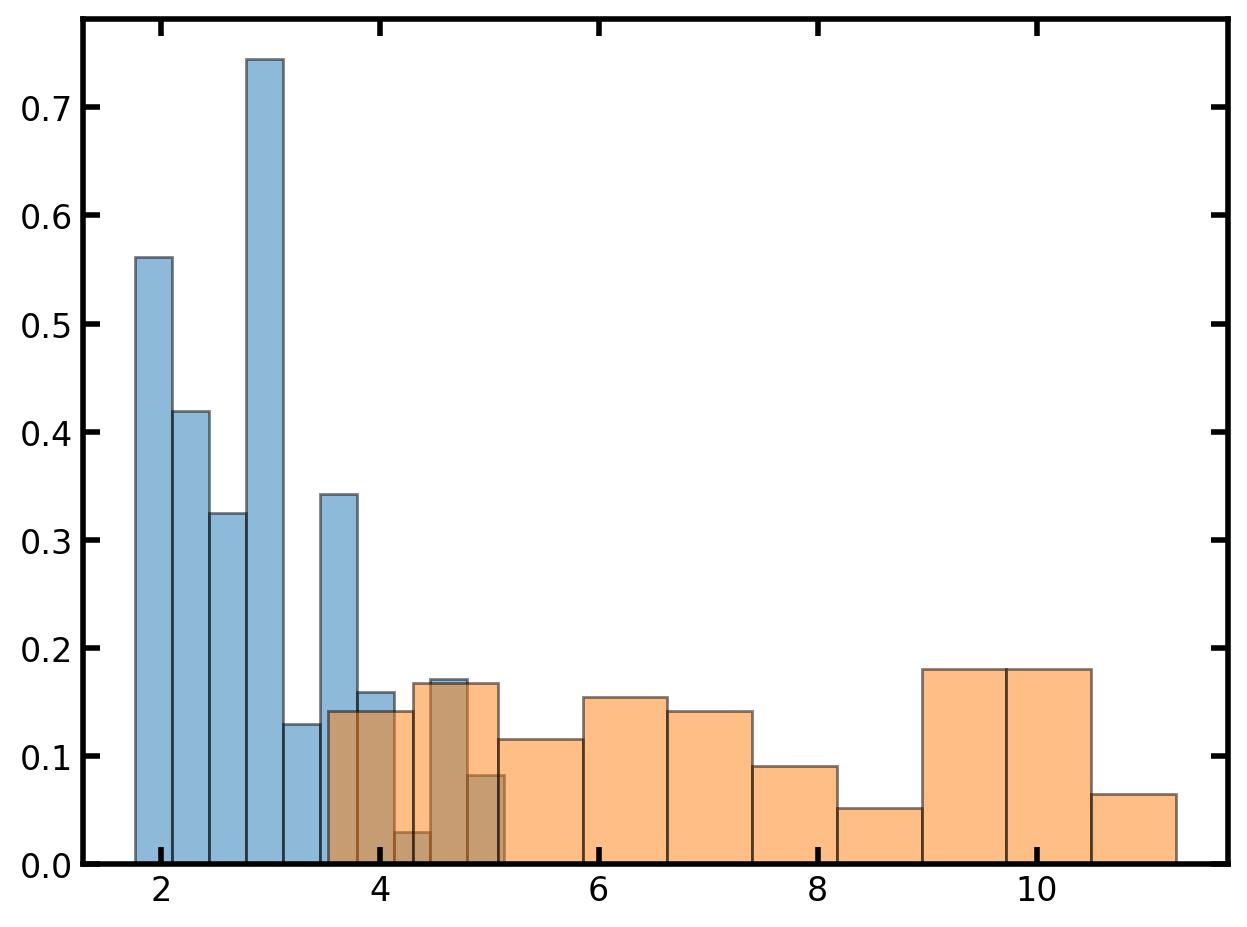

In [ ]:
plt.hist(pn['throat.diameter'], edgecolor='k', density=True, alpha=0.5)
plt.hist(pn['pore.diameter'], edgecolor='k', density=True, alpha=0.5)

In [ ]:
# This simple demo network is prequipped with sphere and cylinder model.
print(pn.models)

# We can also add a model to a network that does not have one:
#pn.add_model_collection(op.models.collections.geometry.spheres_and_cylinders)
#pn.regenerate_models()

―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
#   Property Name                       Parameter                 Value
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
1   pore.coordination_number@all        model:                    coordination_number
                                        regeneration mode:        deferred
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
2   throat.spacing@all                  model:                    pore_to_pore_distance
                                        regeneration mode:        deferred
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
3   pore.seed@all                       model:                    random
                                        element:                  pore
                                        num_range:                [0.2, 0.7]
                                       

In [8]:
water = op.phase.Phase(network=pn)

#water.add_model(propname='pore.viscosity',model=op.models.phase.viscosity.water_correlation)
#print(water)

water['pore.viscosity']=1.0
water.add_model_collection(op.models.collections.physics.basic)
water.regenerate_models()
print(water)

[16:00:53] WARNING  throat.entry_pressure was not run since the following property is missing:       ]8;id=135975;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py\_models.py]8;;\:]8;id=5824;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py#480\480]8;;\
                    'throat.surface_tension'                                                                       

           WARNING  throat.diffusive_conductance was not run since the following property is         ]8;id=507129;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py\_models.py]8;;\:]8;id=438969;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py#480\480]8;;\
                    missing: 'throat.diffusivity'                                                                  


══════════════════════════════════════════════════════════════════════════════
phase_01 : <openpnm.phase.Phase at 0x2428ac298b0>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.temperature                                                100 / 100
  3  pore.pressure                                                   100 / 100
  4  pore.viscosity                                                  100 / 100
  5  throat.hydraulic_conductance                                    502 / 502
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Labels                                                 Assigned Locations
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.all                                                              100
 

In [ ]:
print(water['pore.viscosity'])
print(water['throat.viscosity'])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 

In [9]:
# Calculate throat conductance based on the Hagen Poiseulle model
R = pn['throat.diameter']/2
L = pn['throat.length']
mu = water['throat.viscosity']  
water['throat.hydraulic_conductance'] = np.pi*R**4/(8*mu*L)
print(water['throat.hydraulic_conductance'])

[0.3667341  0.32019535 0.08739736 0.42039234 0.05047748 0.20653534
 0.46720958 0.05205537 0.36206678 0.19385452 0.97198079 0.06466601
 1.11955871 0.50954295 0.027328   0.44866803 0.78920903 0.02426822
 0.074134   2.74527306 0.01022214 0.35862998 0.04258151 0.04460696
 0.04694613 0.33147248 0.09858578 0.53590043 0.54185425 0.03528132
 0.05854078 0.17530373 0.06569983 0.68234917 0.38403435 1.66002268
 0.56634151 0.45723718 0.0126378  0.08242476 2.50863483 0.09991853
 0.16884539 0.00981693 0.00923548 0.01363791 0.01525837 0.01525761
 0.01351364 0.01387562 0.0123923  0.03098285 0.02519509 0.02256422
 0.02169178 0.0309961  0.02416506 0.02201698 0.02792814 0.05741922
 0.33245969 0.04514439 0.03166127 2.0449277  1.65086991 0.11529866
 2.64627847 0.16847954 0.65171007 0.23485849 2.14186574 0.38164872
 0.54881199 0.05194316 0.65177413 0.29351945 0.2050576  2.15580818
 0.04399351 0.03850703 0.04332635 1.98700855 0.30865949 0.02030243
 0.01487425 0.02993    0.01853359 0.0293945  0.03123205 0.0236

In [10]:
# Pressure driven low Reynolds number flow algorithm
sf = op.algorithms.StokesFlow(network=pn, phase=water)
print(sf)

inlet = pn.pores('inlet')
outlet = pn.pores('outlet')

# Assign bounday conditions to left and right boundaries
#To calculate permeability in x direction, a constant pressure boundary condition is applied on the left and right side of the network.
sf.set_value_BC(inlet, values=1)  
sf.set_value_BC(outlet, values=0)
print(sf)


# Run
soln = sf.run()
water.update(sf.soln)



══════════════════════════════════════════════════════════════════════════════
stokes_01 : <openpnm.algorithms.StokesFlow at 0x2428ac3f160>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.bc.rate                                                      0 / 100
  3  pore.bc.value                                                     0 / 100
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Labels                                                 Assigned Locations
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.all                                                              100
  3  throat.all                                                            502
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

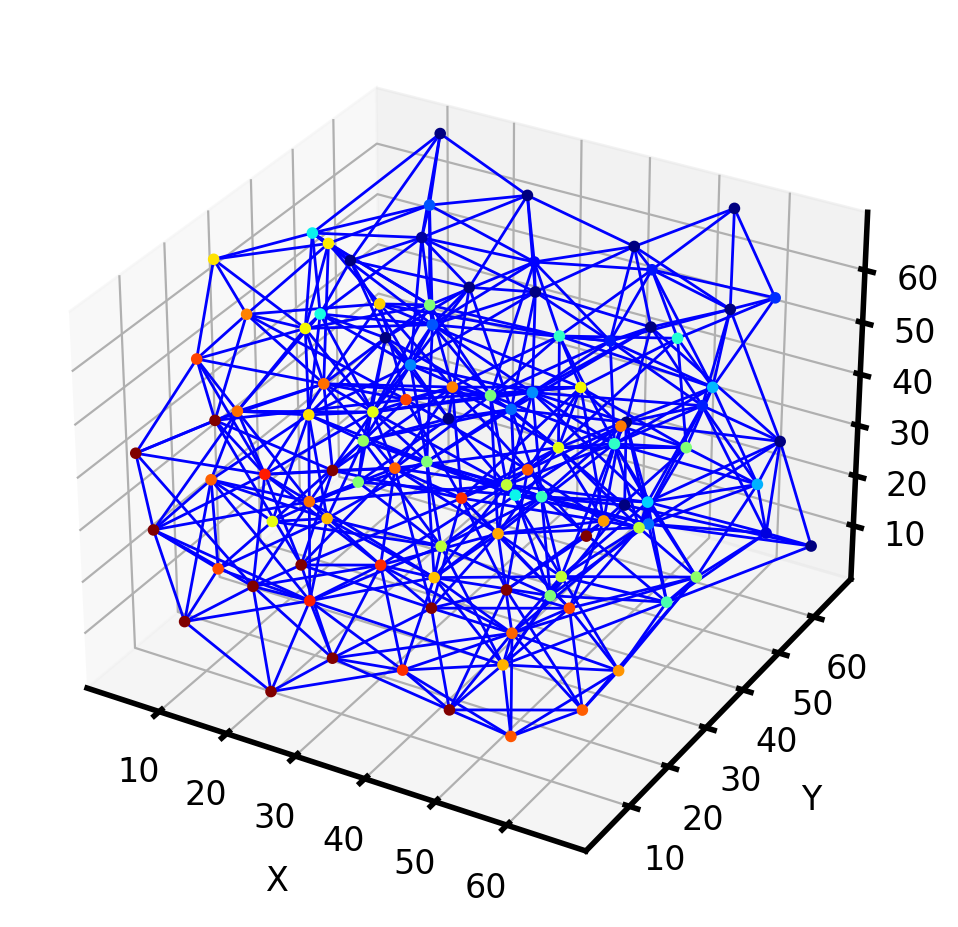

In [ ]:
ax = op.visualization.plot_connections(pn)
ax = op.visualization.plot_coordinates(pn, ax=ax, color_by=water['pore.pressure'])

In [11]:
# This section needs review. Pores are not coplanar (so it needs some rework...)
Q = sf.rate(pores=inlet, mode='group')[0]
A = op.topotools.get_domain_area(pn, inlets=inlet, outlets=outlet)
L = op.topotools.get_domain_length(pn, inlets=inlet, outlets=outlet)
# K = Q * L * mu / (A * Delta_P) # mu and Delta_P were assumed to be 1.
K = Q * L / A
print(f'The value of K is: {K/0.98e-12*1000:.2f} mD')

[16:01:14] WARNING  Attempting to estimate inlet area...will be low                              ]8;id=115020;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=281614;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py#1046\1046]8;;\

           ERROR    Detected inlet pores are not coplanar                                        ]8;id=904003;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=728759;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py#1052\1052]8;;\

           ERROR    Detected outlet pores are not coplanar                                       ]8;id=952684;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=158596;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py#1054\1054]8;;\

           WARNING  Detected inlets are not oriented along a principle axis                      ]8;id=680185;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=320759;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py#1057\1057]8;;\

           WARNING  Detected outlets are not oriented along a principle axis                     ]8;id=702216;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=938108;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py#1060\1060]8;;\

...

           WARNING  Attempting to estimate domain length...could be low if boundary pores were   ]8;id=656648;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=822934;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py#1090\1090]8;;\
                    not added                                                                                      

           ERROR    Detected inlet pores are not coplanar                                        ]8;id=692572;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=614440;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py#1094\1094]8;;\

           ERROR    Detected inlet pores are not coplanar                                        ]8;id=985474;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=185977;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py#1096\1096]8;;\

           ERROR    A unique value of length could not be found                                  ]8;id=947412;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=343272;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py#1100\1100]8;;\

The value of K is: 22963091935964.87 mD
